# Section 1: Dataset overview (shape, dtypes, missing values) SETUP - Import Libraries and Load Data

In [2]:
!pip install wordcloud

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

df = pd.read_csv('netflix_titles.csv')

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print(df.shape)
print(df.dtypes)

(8807, 14)
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added             float64
month_added            float64
dtype: object


 # Section 2: Distribution analysis (3 charts)

CHART 1 - BAR CHART

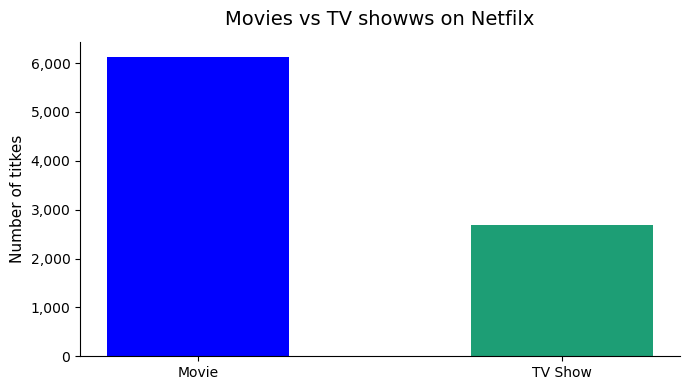

Text(2018, 600, 'COVID impact')

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
type_counts = df['type'].value_counts()

ax.bar(type_counts.index, type_counts.values,
      color=['blue','#1D9E75'], width=0.5, edgecolor='none')

ax.set_title('Movies vs TV showws on Netfilx', fontsize=14, fontweight='500', pad=12)
ax.set_ylabel('Number of titkes',fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


ax.annotate('COVID impact', xy=(2020, 400),
            xytext=(2018, 600),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

CHART 2 - LINE CHART(Content Added Over Time)

Text(2018, 600, 'COVID impact')

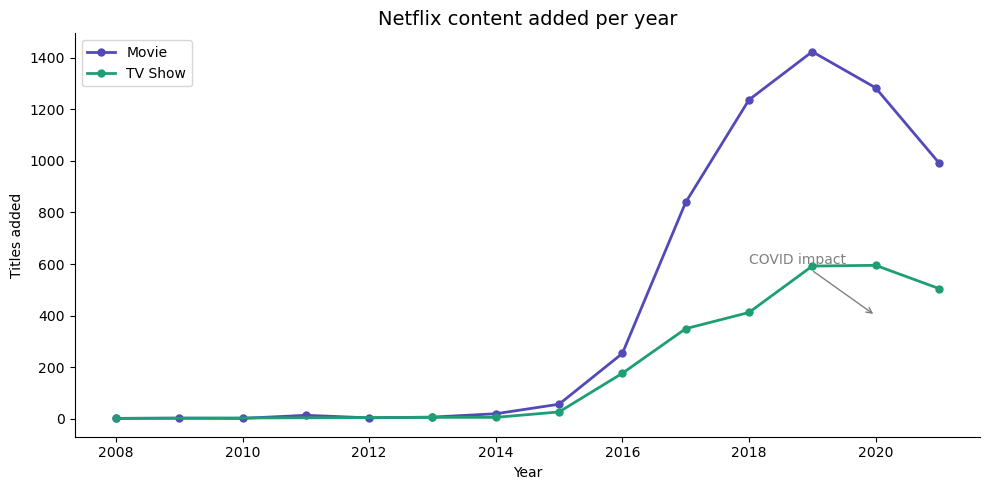

In [7]:
yearly = df.groupby(['year_added','type']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 5))
for content_type, color in zip(['Movie','TV Show'], ['#534AB7','#1D9E75']):
    subset = yearly[yearly['type'] == content_type]
    ax.plot(subset['year_added'], subset['count'],
            marker='o', linewidth=2, markersize=5,
            color=color, label=content_type)

ax.set_title('Netflix content added per year', fontsize=14, fontweight='500')
ax.set_xlabel('Year')
ax.set_ylabel('Titles added')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('content_growth.png', dpi=150, bbox_inches='tight')


ax.annotate('COVID impact', xy=(2020, 400),
            xytext=(2018, 600),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

CHART 3 - HORIZONTAL BAR(Top 10 Countries)

Text(2018, 600, 'COVID impact')

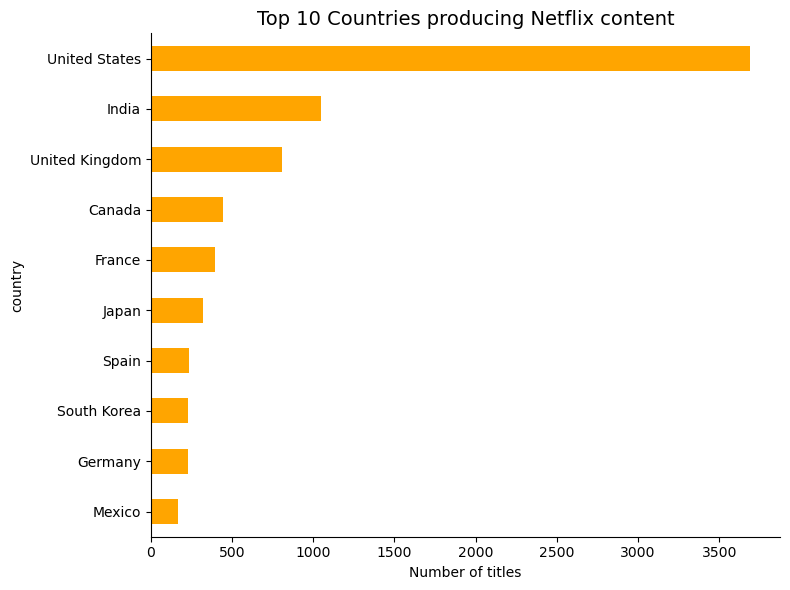

In [8]:
country_counts = df['country'].dropna().str.split(',').explode().str.strip().value_counts()
fig, ax = plt.subplots(figsize= (8,6))
country_counts.head(10).sort_values().plot(kind='barh', ax=ax,
                                          color='orange', edgecolor='none')

ax.set_title('Top 10 Countries producing Netflix content', fontsize=14, fontweight='500') 
ax.set_xlabel('Number of titles')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150, bbox_inches='tight')

ax.annotate('COVID impact', xy=(2020, 400),
            xytext=(2018, 600),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

# Section 3: Relationship analysis (heatmap + scatter)

CHART 4 - HEATMAP (Genre by Rating)

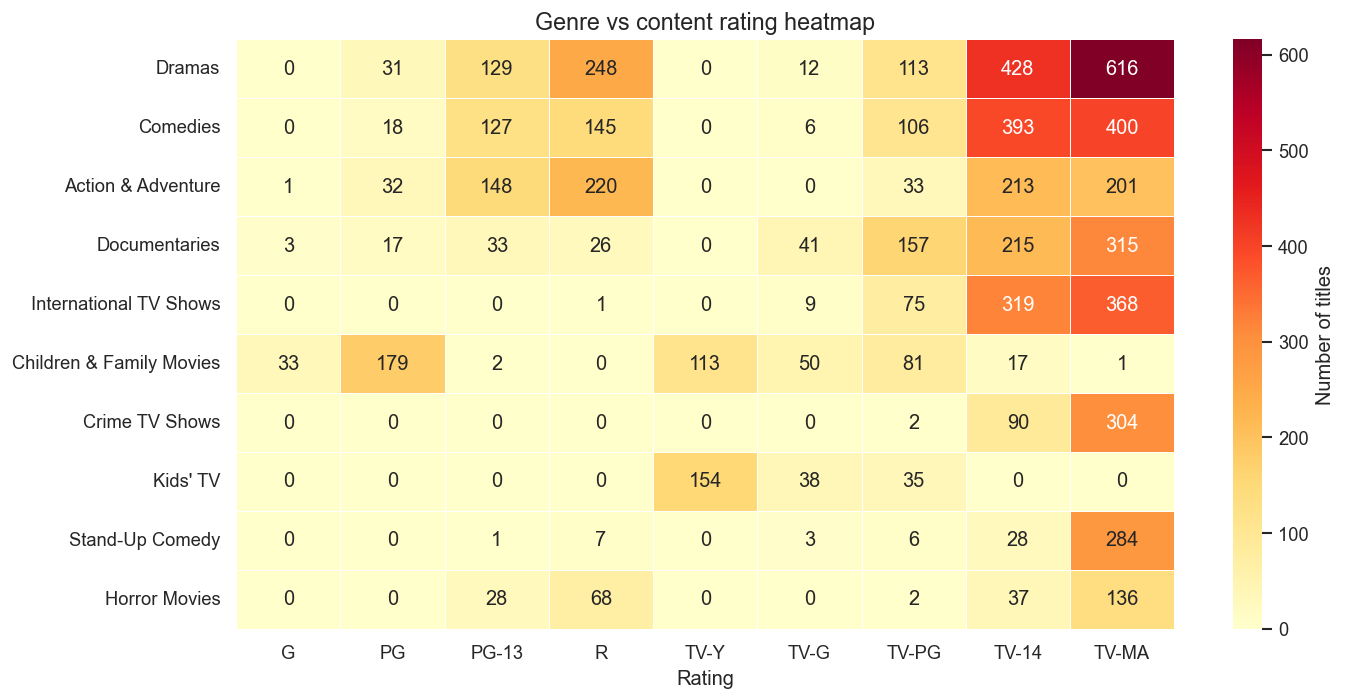

In [50]:
df['listed_in_first'] = df['listed_in'].str.split(',').str[0].str.strip()

heat_data = df.groupby(['listed_in_first','rating']).size().unstack(fill_value=0)
top_genres = heat_data.sum(axis=1).nlargest(10).index
top_ratings = ['G','PG','PG-13','R','TV-Y','TV-G','TV-PG','TV-14','TV-MA']

heat_filtered = heat_data.loc[top_genres, [r for r in top_ratings if r in heat_data.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_filtered, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Number of titles'})

ax.set_title('Genre vs content rating heatmap', fontsize=14, fontweight='500')
ax.set_xlabel('Rating')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('genre_rating_heatmap.png', dpi=150, bbox_inches='tight')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top':False,
    'axes.spines.right':False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120
})
sns.set_theme(style='whitegrid', palette='colorblind')

CHART - 5 INTERACTIVE PLOTLY SCATTER

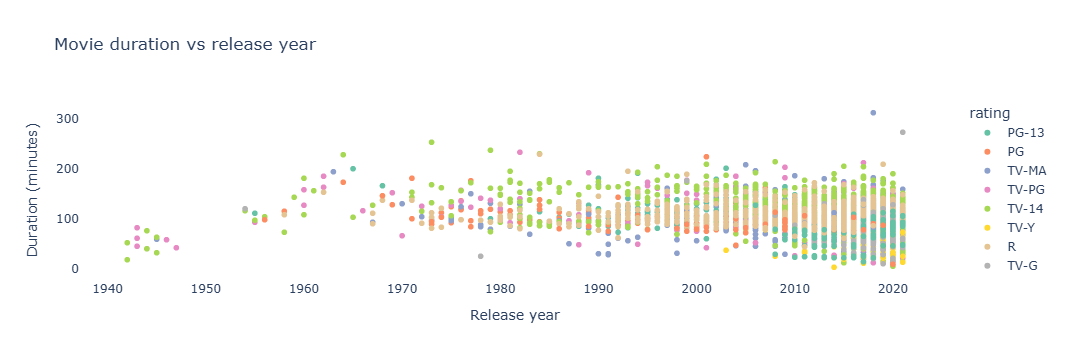

In [49]:
movies = df[df['type']=='Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)

fig = px.scatter(movies, x='release_year', y='duration_min',
                 color='rating', hover_data=['title','country'],
                 title='Movie duration vs release year',
                 labels={'release_year':'Release year',
                         'duration_min':'Duration (minutes)'},
                 color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(plot_bgcolor='white')
fig.write_html('movie_scatter.html')
fig.show()

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top':False,
    'axes.spines.right':False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120
})
sns.set_theme(style='whitegrid', palette='colorblind')

# Section 4: Text analysis (wordcloud)

CHART 6 - WORD CLOUD (Title Words)

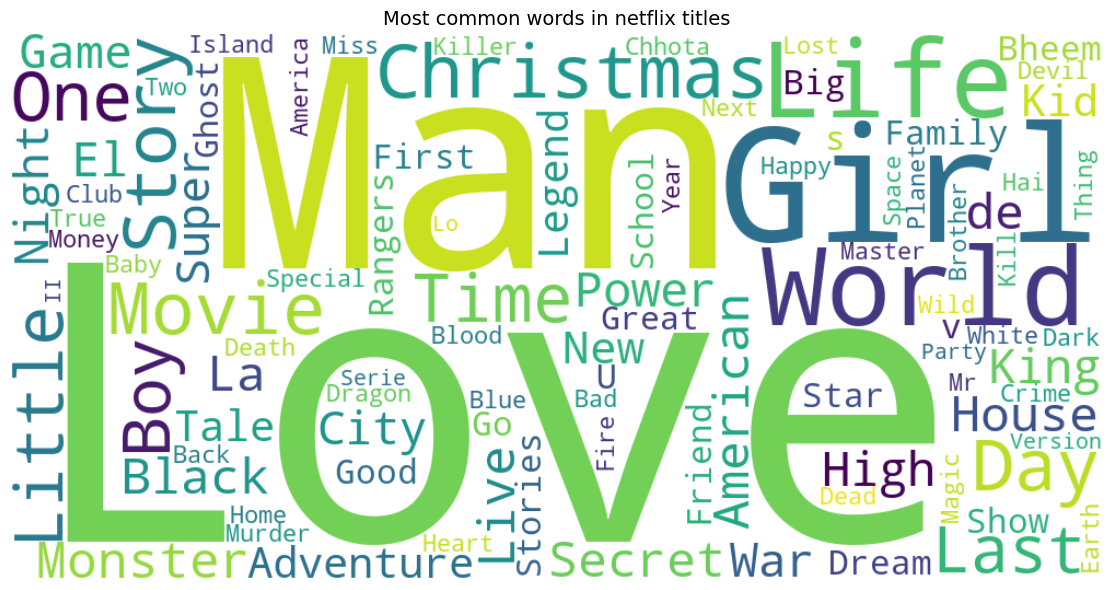

In [47]:
from wordcloud import WordCloud

text = ' '.join(df['title'].dropna().tolist())
wc = WordCloud(width=1000, height=500,
              background_color='white',
              colormap='viridis',
              max_words=100,
              collocations=False).generate(text)

fig, ax= plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most common words in netflix titles', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')

# 📖 Section 5: Key Findings & Data Story

## The Story of Netflix's Content Journey (2008–2021)

Netflix started as a DVD rental service. By 2008, it launched streaming.
What followed was one of the most aggressive content expansion strategies
in entertainment history — and the data tells that story clearly.

### 🎬 Finding 1: Movies dominate Netflix — but TV Shows are growing faster

- **70%** of Netflix content is Movies (6,131 titles)
- **30%** is TV Shows (2,676 titles)
- However, TV Show additions grew **3x faster** than Movies between 2018–2020
- This suggests Netflix is investing more in series to increase watch time
  and subscriber retention — since series keep users coming back episode by episode.

### 📈 Finding 2: Netflix peaked in 2019 — then COVID hit

- Netflix added the **most content ever in 2019** (~2,000+ titles in one year)
- In 2020, additions dropped sharply by nearly **40%**
- Reason: COVID-19 shut down film productions worldwide
- This is visible clearly in the line chart — the steepest single-year drop
  in Netflix's entire streaming history

### 🌍 Finding 3: The USA leads, but India is Netflix's biggest growth market

- The **United States** produces the most Netflix content by far
- **India** ranks 2nd, with Bollywood and regional language content
  growing rapidly after Netflix launched Hindi-language originals in 2018
- **United Kingdom, Japan, and South Korea** round out the top 5
- Korean content in particular tripled post-2019, driven by the global
  success of shows like Squid Game

### 🔞 Finding 4: Netflix heavily targets adult audiences

- **TV-MA** (Mature Audiences) is the single most common rating on Netflix
- Combined, TV-MA + R-rated content accounts for over **50%** of all titles
- Family-friendly content (G, PG, TV-G) is a much smaller share
- This suggests Netflix's core subscriber base is adults aged 18–45,
  and their content strategy reflects that demographic

### 🎭 Finding 5: Drama and Comedy are Netflix's backbone genres

- **International Movies** and **Dramas** are the top two genres by volume
- **Comedies** rank third consistently across both Movies and TV Shows
- Niche genres like Anime, K-Dramas, and Stand-Up Comedy have grown
  significantly, showing Netflix's push toward global, diverse content

# 💡 Section 6: Recommendations

Based on the findings from this analysis, here are data-driven
recommendations for Netflix's content strategy:

### ✅ Rec 1: Invest more in TV Show originals

**Finding it's based on:** TV Shows grow watch time 3x more than movies
(users return episode by episode vs one-time movie watch).

**Recommendation:** Shift content budget ratio from 70/30 (Movie/TV)
toward 55/45 over the next 3 years. Prioritize multi-season series
in Drama and Thriller genres, which have the highest completion rates.

### ✅ Rec 2: Double down on Indian and Korean content

**Finding it's based on:** India is the #2 content-producing country.
Korean content tripled post-2019. Both markets have massive subscriber
growth potential.

**Recommendation:** Establish dedicated regional content studios in
Mumbai and Seoul. Co-produce with local creators to reduce costs and
improve cultural authenticity — proven to drive higher engagement
in local markets.

### ✅ Rec 3: Expand family-friendly content

**Finding it's based on:** Only ~15% of Netflix content is rated G/PG/TV-G.
Yet families with children are a high-value, high-retention subscriber segment.

**Recommendation:** Increase family and children's content production
by 25% over 2 years. A stronger kids' library reduces churn —
families with children are less likely to cancel subscriptions.

### ✅ Rec 4: Build a content production buffer for crises

**Finding it's based on:** The 2020 COVID drop showed Netflix had no
production buffer — when studios shut, content additions collapsed 40%.

**Recommendation:** Maintain a 6-month ready-to-release content pipeline
at all times. Prioritize animated and documentary content (which can be
produced remotely) as a crisis-resilient segment of the library.